# LIBERO Prompt Variant Rollout Analysis

This notebook loads raw rollout output and provides:
- overall statistics
- success-rate heatmap by task and prompt variant
- mean episode-length heatmap by task and prompt variant
- success-rate bar plot by variant with the original prompt as a baseline line

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)

## 2. Load and Parse Raw Output Data

In [2]:
candidate_paths = [
    Path("../language_diagnostics/outputs/libero_prompt_variant_rollouts_raw.csv"),
    Path("language_diagnostics/outputs/libero_prompt_variant_rollouts_raw.csv"),
    Path("outputs/libero_prompt_variant_rollouts_raw.csv"),
]

csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        "Could not find libero_prompt_variant_rollouts_raw.csv. "
        f"Checked: {[str(p) for p in candidate_paths]}"
    )

print(f"Loading data from: {csv_path.resolve()}")
df = pd.read_csv(csv_path)

required_cols = {
    "suite", "task_id", "task_description", "variant_type", "success", "episode_length", "rollout_index"
}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(
        "Missing required columns for analysis: "
        f"{sorted(missing)}. Available columns: {list(df.columns)}"
    )

# Normalize types for robust analysis.
df["success"] = df["success"].astype(bool)
df["episode_length"] = pd.to_numeric(df["episode_length"], errors="coerce")

# Build labels: keep a rich label for tables and a compact one for heatmaps.
df["task_label"] = (
    df["suite"].astype(str)
    + " | task_"
    + df["task_id"].astype(str)
    + " | "
    + df["task_description"].astype(str).str.slice(0, 55)
)

df["task_short"] = (
    df["suite"].astype(str)
    + " | t"
    + df["task_id"].astype(str)
    + " | "
    + np.where(
        df["task_description"].str.len() > 28,
        df["task_description"].str.slice(0, 28) + "…",
        df["task_description"],
    )
)

print(f"Rows (rollouts): {len(df)}")
print(f"Unique tasks: {df['task_label'].nunique()}")
print(f"Unique variants: {df['variant_type'].nunique()}")
df.head()

Loading data from: /zhome/ca/2/206287/vla-robotics/language_diagnostics/outputs/libero_prompt_variant_rollouts_raw.csv
Rows (rollouts): 270
Unique tasks: 6
Unique variants: 9


,suite,task_id,task_description,episode_seed_base,variant_type,variant_index,prompt,rollout_index,episode_seed,success,episode_length,task_label,task_short
0,spatial,0,pick up the black bowl between the plate and t...,0,original,0,pick up the black bowl between the plate and t...,0,0,True,81,spatial | task_0 | pick up the black bowl betw...,spatial | t0 | pick up the black bowl betwe…
1,spatial,0,pick up the black bowl between the plate and t...,0,original,0,pick up the black bowl between the plate and t...,1,1,True,79,spatial | task_0 | pick up the black bowl betw...,spatial | t0 | pick up the black bowl betwe…
2,spatial,0,pick up the black bowl between the plate and t...,0,original,0,pick up the black bowl between the plate and t...,2,2,True,73,spatial | task_0 | pick up the black bowl betw...,spatial | t0 | pick up the black bowl betwe…
3,spatial,0,pick up the black bowl between the plate and t...,0,original,0,pick up the black bowl between the plate and t...,3,3,True,71,spatial | task_0 | pick up the black bowl betw...,spatial | t0 | pick up the black bowl betwe…
4,spatial,0,pick up the black bowl between the plate and t...,0,original,0,pick up the black bowl between the plate and t...,4,4,True,70,spatial | task_0 | pick up the black bowl betw...,spatial | t0 | pick up the black bowl betwe…


## 3. Calculate Overall Statistics

In [3]:
overall = {
    "num_rollouts": len(df),
    "num_tasks": df["task_label"].nunique(),
    "num_variants": df["variant_type"].nunique(),
    "overall_success_rate": df["success"].mean(),
    "overall_mean_episode_length": df["episode_length"].mean(),
    "overall_median_episode_length": df["episode_length"].median(),
}

overall_df = pd.DataFrame([overall])
overall_df[["overall_success_rate"]] = overall_df[["overall_success_rate"]] * 100
overall_df = overall_df.rename(columns={"overall_success_rate": "overall_success_rate_percent"})
display(overall_df.round(2))

per_variant = (
    df.groupby("variant_type", as_index=False)
    .agg(
        rollouts=("success", "size"),
        success_rate=("success", "mean"),
        mean_episode_length=("episode_length", "mean"),
        median_episode_length=("episode_length", "median"),
    )
    .sort_values("success_rate", ascending=False)
)
per_variant["success_rate_percent"] = per_variant["success_rate"] * 100
display(per_variant.round(2))

,num_rollouts,num_tasks,num_variants,overall_success_rate_percent,overall_mean_episode_length,overall_median_episode_length
0,270,6,9,34.07,228.01,280.0


,variant_type,rollouts,success_rate,mean_episode_length,median_episode_length,success_rate_percent
3,original,30,0.80,149.63,128.0,80.00
7,verb_paraphrase,30,0.60,187.27,167.0,60.00
5,quickly,30,0.57,191.17,144.5,56.67
4,politeness,30,0.47,215.97,280.0,46.67
0,carefully,30,0.30,249.67,280.0,30.00
6,sentence_structure,30,0.13,254.23,280.0,13.33
2,do_not_move,30,0.13,253.07,280.0,13.33
1,contrastive_negation,30,0.07,271.13,280.0,6.67
8,verbosity,30,0.00,280.00,280.0,0.00


## 4. Create Success vs Task Heatmap

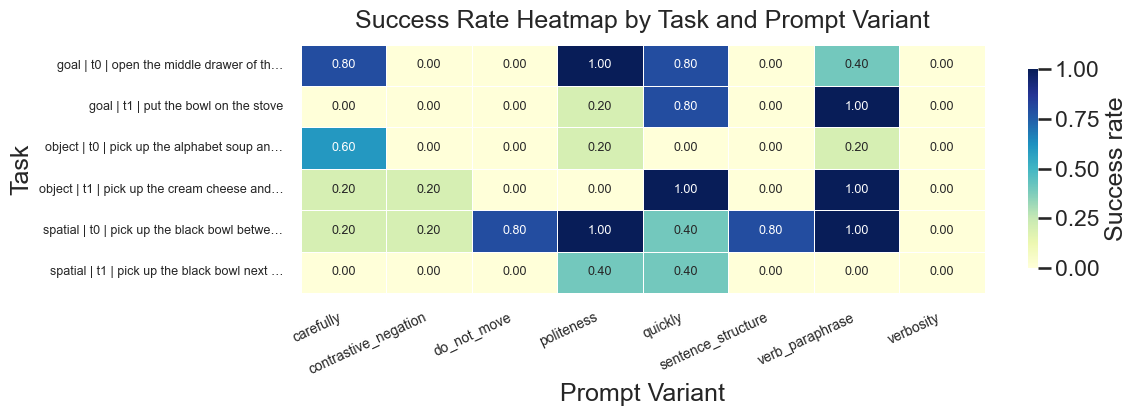

In [4]:
success_pivot = (
    df[df["variant_type"] != "original"]
    .groupby(["task_short", "variant_type"], as_index=False)["success"]
    .mean()
    .pivot(index="task_short", columns="variant_type", values="success")
)

n_tasks = len(success_pivot)
fig_h = min(max(4.5, 0.45 * n_tasks), 11)

plt.figure(figsize=(12, fig_h))
ax = sns.heatmap(
    success_pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Success rate", "shrink": 0.8},
    annot_kws={"size": 9},
)
ax.set_title("Success Rate Heatmap by Task and Prompt Variant", pad=12)
ax.set_xlabel("Prompt Variant")
ax.set_ylabel("Task")
ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=10)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 5. Create Mean Episode Length vs Task Heatmap

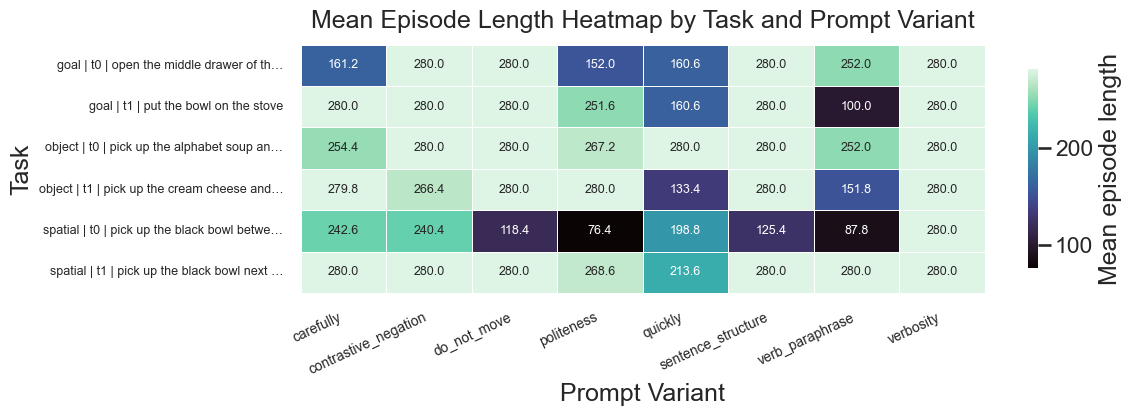

In [5]:
length_pivot = (
    df[df["variant_type"] != "original"]
    .groupby(["task_short", "variant_type"], as_index=False)["episode_length"]
    .mean()
    .pivot(index="task_short", columns="variant_type", values="episode_length")
)

n_tasks = len(length_pivot)
fig_h = min(max(4.5, 0.45 * n_tasks), 11)

plt.figure(figsize=(12, fig_h))
ax = sns.heatmap(
    length_pivot,
    annot=True,
    fmt=".1f",
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean episode length", "shrink": 0.8},
    annot_kws={"size": 9},
)
ax.set_title("Mean Episode Length Heatmap by Task and Prompt Variant", pad=12)
ax.set_xlabel("Prompt Variant")
ax.set_ylabel("Task")
ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=10)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 6. Create Success Rate Bar Plot with Baseline Comparison

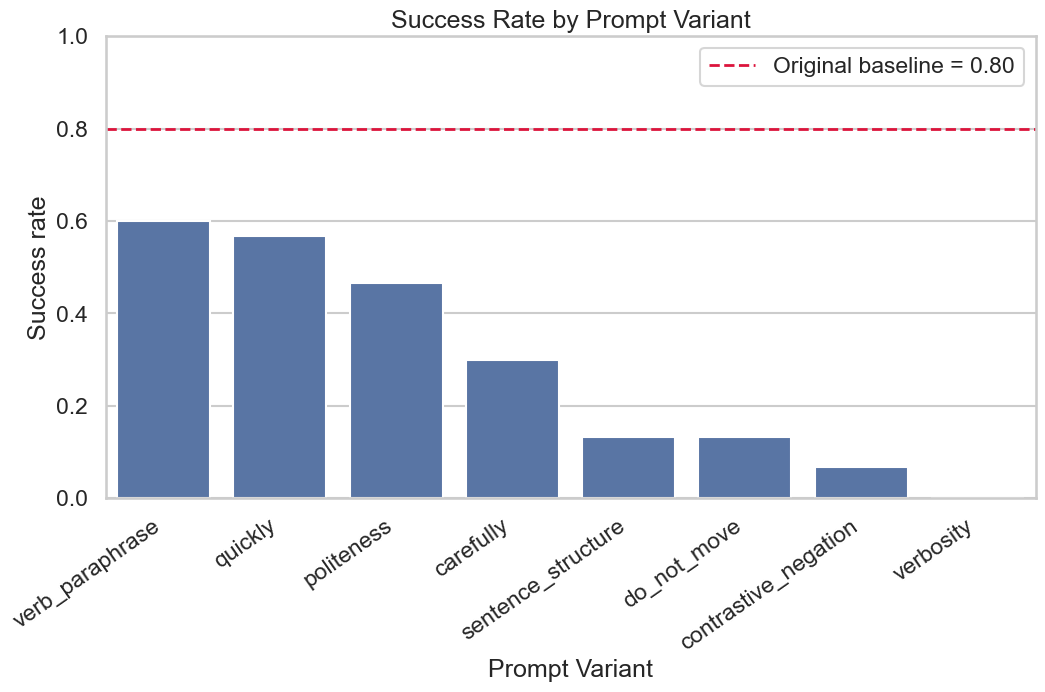

<Figure size 640x480 with 0 Axes>

In [6]:
variant_success = (
    df.groupby("variant_type", as_index=False)["success"]
    .mean()
    .sort_values("success", ascending=False)
)

original_row = variant_success.loc[variant_success["variant_type"] == "original", "success"]
if original_row.empty:
    raise ValueError("No 'original' variant found in data. Cannot draw baseline line.")
original_baseline = float(original_row.iloc[0])

# Remove 'original' from the bar plot (keep only variants)
variant_success_plot = variant_success[variant_success["variant_type"] != "original"]

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=variant_success_plot, x="variant_type", y="success", color="#4C72B0")
ax.axhline(
    original_baseline,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Original baseline = {original_baseline:.2f}",
)
ax.set_title("Success Rate by Prompt Variant")
ax.set_xlabel("Prompt Variant")
ax.set_ylabel("Success rate")
ax.set_ylim(0, 1)
plt.xticks(rotation=35, ha="right")

ax.legend()
plt.show()
plt.tight_layout()